<style>
.retail-container{
    width:100%;
    max-width:1200px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.retail-header{
    text-align:center;
    margin-bottom:6px;
}

.retail-header h1{
    color:#b45309;
    font-size: clamp(1.4rem, 3.2vw, 2.2em);
    font-weight:700;
    margin:0 0 6px 0;
}

.retail-header h3{
    color:#7c2d12;
    margin:0;
    font-weight:500;
    font-size: clamp(0.95rem, 1.8vw, 1.1rem);
}

.retail-intro p{ font-size: clamp(0.98rem, 1.6vw, 1.08em); margin-bottom:10px; }

.retail-list{ font-size: clamp(0.95rem, 1.6vw, 1.05em); color:#3b2b20; margin-left:25px; margin-bottom:18px; }

.meta-cards{
    display:flex;
    justify-content:space-between;
    flex-wrap:wrap;
    gap:14px;
    margin:20px 0;
}

.meta-card{
    flex:1;
    min-width:220px;
    background:rgba(255,255,255,0.75);
    padding:14px 16px;
    border-radius:12px;
    border:1px solid rgba(250, 164, 76, 0.25);
    box-shadow: 0 2px 8px rgba(250,164,76,0.1);
}

.meta-card p{ margin:6px 0; font-size:0.99rem; color:#3b2b20; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.objectives{ font-size: clamp(0.95rem, 1.6vw, 1.05em); color:#3b2b20; margin-left:25px; }

.note{
    margin-top:24px;
    margin-bottom:24px;
    padding:14px 6px 14px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

@media (max-width:760px){
    .meta-cards{ flex-direction:column; }
    .meta-card{ max-width:90%; }
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<div class="retail-header">
    <h1>🚦 EXPLORATION DES DONNÉES – US ACCIDENTS</h1>
    <h3><em>Projet NGO – Analyse statistique avancée des accidents de la route (2016 - 2023)</em></h3>
</div>

<hr>

<div class="retail-intro">
<h2 class="section-title">🎯 Objectifs de l'exploration</h2>

<ol class="objectives">
     <li><strong>Comprendre</strong> la structure, la granularité et la qualité du dataset US-Accidents</li>
    <li><strong>Identifier</strong> les valeurs manquantes, incohérences et outliers pouvant biaiser l’analyse</li>
    <li><strong>Explorer</strong> les patterns spatio-temporels (heures, jours, saisons, États)</li>
    <li><strong>Analyser</strong> l’impact de la météo, de l’infrastructure routière et du temps sur la gravité des accidents</li>
    <li><strong>Préparer</strong> les données pour des statistiques avancées, modélisation et reporting grand public</li>
</ol>
</div>

<div class="meta-cards">

  <div class="meta-card">
      <p><strong>📁 Dataset :</strong><br>
      <code style="background:rgba(255,249,240,0.8); color:#92400e; padding:3px 8px; border-radius:6px;">
        US_Accidents_(Sample_500k).csv
      </code></p>
      <p><strong>📊 Volume :</strong> ~7 000 000 accidents</p>
      <p><strong>🌍 Couverture :</strong> 49 États – États-Unis</p>
  </div>

  <div class="meta-card">
      <p><strong>🗓️ Période analysée :</strong><br> Février 2016 → Mars 2023</p>
      <p><strong>⏱️ Phase d’analyse :</strong> 05 → 16 janvier 2026</p>
      <p><strong>🎯 Finalité :</strong> Amélioration de la sécurité routière</p>
  </div>

  <div class="meta-card">
      <p>
        <strong>👥 Équipe :</strong><br>
        Asmae Janah<br>
        Zineb Ettahery<br>
        Hajar Mamdoug<br>
        Safia Daoudi
      </p>
  </div>

</div>

<hr>

<div class="note">
<strong>📌 Note méthodologique :</strong><br>
Cette phase d’exploration (EDA) constitue la base de toutes les analyses statistiques avancées
du projet. Les observations issues de cette étape guideront les choix de tests, modèles
(statistiques, GLM, séries temporelles, ACP) et permettront de produire un reporting clair,
fiable et compréhensible pour un public non technique.
</div>

</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des donnees</T1>

In [4]:
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
import dask.dataframe as dd
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import time
import os

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement & Structure Initiale</T1>

In [5]:
# Masquer la fenêtre principale Tkinter
root = Tk()
root.withdraw()

# Forcer la fenêtre à être au premier plan
root.attributes('-topmost', True)
root.update()

# Ouvrir la fenêtre de sélection
fichier = filedialog.askopenfilename(
    title="Choisissez le fichier à analyser",
    filetypes=[("Fichiers CSV", "*.csv"), ("Fichiers Excel", "*.xlsx *.xls"), ("Tous les fichiers", "*.*")]
)

In [6]:
# Lecture du fichier sélectionné avec pandas
df = pd.read_csv(fichier)

In [4]:
# Faire une copie du DataFrame pandas
dfA = df.copy()

In [ ]:
dfA.head(2000).to_csv(
    "C:/Users/pc/Desktop/dfA_2000.csv",
    index=False
)


In [ ]:
# Afficher les premières lignes du DataFrame
df.head()

In [ ]:
# nombre de lignes et de colonnes
shape_data = dfA.shape
print(f'Le jeu de donnees contient {shape_data[0]} lignes et {shape_data[1]} colonnes.')

In [ ]:
# noms des colonnes
dfA.columns

In [ ]:
# types de colonnes
dfA.info()

<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbaf 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.data-info, .column-table{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
}

.data-info ul{
    list-style-type: "📊 ";
    padding-left:20px;
    margin-top:10px;
}

.column-table{
    width:100%;
    border-collapse: collapse;
    margin-top:16px;
}

.column-table th{
    background:#b45309;
    color:#fff;
    padding:10px;
    text-align:left;
    font-weight:600;
    border-radius:4px 4px 0 0;
}

.column-table td{
    background:rgba(255,255,255,0.85);
    padding:8px 10px;
    border-bottom:1px solid rgba(251,146,60,0.25);
}

.column-table tr:hover td{
    background:rgba(197, 93, 7, 0.81);
    color: #ffffff;
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
    color:#fff;
    padding:2px 6px;
    border-radius:6px;
}

@media (max-width:760px){
    .column-table td, .column-table th{
        font-size:0.9em;
        padding:6px;
    }
}
</style>

<div class="retail-container">

<h2 class="section-title">🚦 Observations Initiales — Dataset Accidents Routiers</h2>

<div class="data-info">
<h3 style="color:#7c2d12;">Structure globale du dataset :</h3>
<ul>
    <li><strong>Nombre total de lignes :</strong> 7 728 394 accidents</li>
    <li><strong>Nombre total de colonnes :</strong> 46 variables</li>
    <li><strong>Nature des données :</strong> Spatio-temporelles, météorologiques et infrastructurelles</li>
</ul>
</div>

<hr>

<h3 style="color:#7c2d12;">Principales catégories de variables :</h3>

<table class="column-table">
    <thead>
        <tr>
            <th>Catégorie</th>
            <th>Colonnes concernées</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Identification</td>
            <td>ID, Source</td>
            <td>Identification unique et provenance des données</td>
        </tr>
        <tr>
            <td>Sévérité & Temps</td>
            <td>Severity, Start_Time, End_Time</td>
            <td>Niveau de gravité et temporalité de l’accident</td>
        </tr>
        <tr>
            <td>Localisation</td>
            <td>Start_Lat, Start_Lng, End_Lat, End_Lng</td>
            <td>Coordonnées géographiques précises</td>
        </tr>
        <tr>
            <td>Adresse</td>
            <td>Street, City, County, State, Zipcode</td>
            <td>Informations administratives et géographiques</td>
        </tr>
        <tr>
            <td>Météo</td>
            <td>Temperature, Humidity, Wind, Visibility, Weather_Condition</td>
            <td>Conditions climatiques au moment de l’accident</td>
        </tr>
        <tr>
            <td>Infrastructure</td>
            <td>Traffic_Signal, Junction, Crossing, Stop, Railway…</td>
            <td>Présence d’éléments routiers spécifiques</td>
        </tr>
        <tr>
            <td>Luminosité</td>
            <td>Sunrise_Sunset, Civil/Nautical/Astronomical_Twilight</td>
            <td>Conditions de lumière naturelle</td>
        </tr>
    </tbody>
</table>

<div class="alert">
⚠️ <strong>Points critiques détectés :</strong><br>
- Les colonnes <code>Start_Time</code>, <code>End_Time</code> et <code>Weather_Timestamp</code> sont en type <code>object</code> → conversion vers <code>datetime</code> indispensable.<br>
- Le volume du dataset (&gt; 7 millions de lignes) nécessite l’utilisation de <strong>Dask</strong> ou d’un échantillonnage pour l’EDA.<br>
- Plusieurs variables météorologiques contiennent des valeurs manquantes (<code>NaN</code>) → traitement requis avant modélisation.
</div>

</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Analyse de Qualité des Données</T1>

In [ ]:
# valeurs manquantes par colonne
valeurs_nulles = dfA.isnull().sum()
taux_valeurs_nulles = round((dfA.isnull().sum() / len(dfA)) * 100, 2)

df_nulles = pd.DataFrame({
    'Colonne': valeurs_nulles.index,
    'Nb_Manquants': valeurs_nulles.values,
    'Pourcentage': taux_valeurs_nulles.values
}).sort_values('Nb_Manquants', ascending=False)

print(df_nulles[df_nulles['Nb_Manquants'] > 0])

In [ ]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
df_nulles_plot = df_nulles[df_nulles['Nb_Manquants'] > 0].sort_values('Pourcentage')
plt.barh(df_nulles_plot['Colonne'], df_nulles_plot['Pourcentage'], color='coral')
plt.xlabel('Pourcentage de valeurs manquantes (%)')
plt.title('Distribution des Valeurs Manquantes par Colonne')
plt.axvline(x=5, color='red', linestyle='--', label='Seuil critique 5%')
plt.legend()
plt.tight_layout()
plt.show()

<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: 30px;
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
    padding-bottom: 30px !important;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.subsection-title{
    color:#7c2d12;
    font-size: clamp(0.95rem, 1.6vw, 1.1em);
    margin:12px 0 4px 0;
    font-weight:600;
}

.retail-list, .detail-list{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
    margin-left:25px;
    margin-bottom:18px;
}

.detail-list li{
    margin-bottom:6px;
}

.note{
    margin-top:16px;
    padding:12px 0px 12px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
    color:#fff;
    padding:2px 6px;
    border-radius:6px;
}

@media (max-width:760px){
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<h2 class="section-title">📊 Analyse des Valeurs Manquantes — Dataset Accidents Routiers</h2>

<div class="alert">
🧠 <strong>Note méthodologique :</strong><br>
- Le <code>seuil critique</code> permet d’identifier les colonnes dont le taux de valeurs manquantes compromet la fiabilité analytique.<br>
- Cette analyse est essentielle compte tenu du volume élevé du dataset (<strong>7,7 millions de lignes</strong>).
</div>

<div class="alert">
💡 <strong>Règle de décision adoptée :</strong><br><br>

- <strong>&lt; 5 % de valeurs manquantes</strong><br>
👉 Impact faible → imputation simple possible (médiane / mode) ou suppression des lignes.<br><br>

- <strong>Entre 5 % et 20 %</strong><br>
👉 Analyse approfondie requise (origine des données, dépendance métier).<br><br>

- <strong>&gt; 20 %</strong><br>
👉 Colonne critique → suppression ou exclusion des analyses principales.
</div>

<hr>

<h3 class="subsection-title">🔴 Colonnes critiques (&gt; 20 % de valeurs manquantes)</h3>

<ul class="detail-list">
    <li><strong>End_Lat</strong> → 44.03 % (coordonnées de fin souvent absentes)</li>
    <li><strong>End_Lng</strong> → 44.03 %</li>
    <li><strong>Precipitation(in)</strong> → 28.51 %</li>
    <li><strong>Wind_Chill(F)</strong> → 25.87 %</li>
</ul>

<div class="note">
👉 Ces variables présentent un fort taux d’incomplétude et seront soit exclues, soit analysées séparément selon leur utilité métier.
</div>

<h3 class="subsection-title">🟠 Colonnes à surveiller (5 % – 10 %)</h3>

<ul class="detail-list">
    <li><strong>Wind_Speed(mph)</strong> → 7.39 %</li>
</ul>

<div class="note">
👉 Une imputation conditionnelle ou par segment temporel pourra être envisagée.
</div>

<h3 class="subsection-title">🟢 Colonnes faiblement impactées (&lt; 5 %)</h3>

<ul class="detail-list">
    <li>Visibility(mi) → 2.29 %</li>
    <li>Wind_Direction → 2.27 %</li>
    <li>Humidity(%) → 2.25 %</li>
    <li>Weather_Condition → 2.24 %</li>
    <li>Temperature(F) → 2.12 %</li>
    <li>Pressure(in) → 1.82 %</li>
    <li>Weather_Timestamp → 1.56 %</li>
    <li>Twilight variables (≈ 0.30 %)</li>
    <li>Airport_Code → 0.29 %</li>
    <li>Street, Timezone, Zipcode, City, Description → &lt; 0.2 %</li>
</ul>

<div class="note">
✅ Ces colonnes sont considérées comme fiables et peuvent être utilisées directement après un nettoyage léger.
</div>

</div>


In [ ]:
# valeur dupliquées
nb_duplicats = df.duplicated().sum()
print(f'Nombre de lignes dupliquées : {nb_duplicats}')

<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.subsection-title{
    color:#7c2d12;
    font-size: clamp(0.95rem, 1.6vw, 1.1em);
    margin:12px 0 4px 0;
    font-weight:600;
}

.retail-list, .detail-list{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
    margin-left:25px;
    margin-bottom:18px;
}

.detail-list li{
    margin-bottom:6px;
}

.note{
    margin-top:16px;
    padding:12px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

.meta-cards{
    display:flex;
    justify-content:space-between;
    flex-wrap:wrap;
    gap:14px;
    margin:20px 0;
}

.meta-card{
    flex:1;
    position: relative;
    min-width:220px;
    background:rgba(255,255,255,0.75);
    padding:14px 16px;
    border-radius:12px;
    border:1px solid rgba(250, 164, 76, 0.25);
    box-shadow: 0 2px 8px rgba(250,164,76,0.1);
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
}

.meta-card p{ margin:6px 0; font-size:0.99rem; color:#3b2b20; }

@media (max-width:760px){
    .meta-cards{ flex-direction:column; }
    .meta-card{ max-width:90%; }
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<h2 class="section-title">📊 Résultats : Valeurs dupliquee</h2>
<div class="alert">
Aucuns doublons dans la dataset 
</div>



</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Analyse globale sur la distribustion</T1>

In [ ]:
# ------------------------------------------------Severity Analysis

# Calcul unique
severity_counts = df["Severity"].value_counts(dropna=False)
severity_percent = round(severity_counts / severity_counts.sum() * 100, 2)

# DataFrame final
result = pd.DataFrame({
    'Severity': severity_counts.index,
    'Nombre': severity_counts.values,
    'Pourcentage (%)': severity_percent.values
})


# Affichage du résultat
plt.figure(figsize=(12, 5))
bars = plt.barh(
    result['Severity'].astype(str),
    result['Nombre'],
    color='teal'
)
plt.title("Répartition de la gravité des accidents (Severity)")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Severity")

# Ajouter les pourcentages sur les barres
for bar, pct in zip(bars, result['Pourcentage (%)']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f' {pct}%',
        va='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------Day vs Night Analysis
plt.figure(figsize=(5, 5))

df['Sunrise_Sunset'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#0f766e', '#f59e0b'],  # Jour / Nuit (teal + amber)
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title("Répartition des accidents : Jour vs Nuit", fontsize=14)
plt.ylabel("")  # Supprimer le label automatique

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------Weather Condition Analysis
plt.figure(figsize=(14, 6))

df['Weather_Condition'].value_counts().head(10).plot(
    kind='bar',
    color='#0f766e',  # teal
    edgecolor='black'
)

plt.title("Top 10 des conditions météo lors des accidents", fontsize=14)
plt.xlabel("Condition météo")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------------------------Temperature Analysis
bins = list(range(-20, 125, 5))  # tranche tous les 5°F

plt.figure(figsize=(14, 6))

df['Temperature(F)'].dropna().plot(
    kind='hist',
    bins=bins,
    edgecolor='black'
)

plt.xticks(bins[::2])  # affiche 1 tick sur 2 pour lisibilité

plt.title("Distribution de la température (pas de 5°F)")
plt.xlabel("Température (°F)")
plt.ylabel("Nombre d'accidents")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------------------------Visibility Analysis
plt.figure(figsize=(14, 6))

df['Visibility(mi)'].dropna().plot(
    kind='hist',
    bins=range(0, 16),  # visibilité de 0 à 15 miles
    edgecolor='black'
)

plt.title("Distribution de la visibilité")
plt.xlabel("Visibilité (miles)")
plt.ylabel("Nombre d'accidents")
plt.xticks(range(0, 16))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------------------------Precipitation Analysis

plt.figure(figsize=(14, 6))

df['Precipitation(in)'].dropna().plot(
    kind='hist',
    bins=10,
    edgecolor='black'
)

plt.title("Distribution des précipitations")
plt.xlabel("Précipitations (inches)")
plt.ylabel("Nombre d'accidents")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------Wind_speed Analysis

plt.figure(figsize=(14, 6))

df['Wind_Speed(mph)'].dropna().plot(
    kind='hist',
    bins=range(0, 40),
    edgecolor='black'
)

plt.title("Distribution de la vitesse du vent lors des accidents")
plt.xlabel("Vitesse du vent (mph)")
plt.ylabel("Nombre d'accidents")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------- Infrastructure Analysis

infra_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

infra_percent = (df[infra_cols].sum() / len(df) * 100).sort_values()

plt.figure(figsize=(14, 7))
infra_percent.plot(
    kind='barh',
    edgecolor='black'
)

plt.title("Pourcentage d'accidents impliquant une infrastructure")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Infrastructure")

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Nettoyage des donnees et Analyse categorielle</T1>

<style>
T1 {
    display: inline-block;
    background: #fde2d2;
    color: #c95305;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 19px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>⌛ Pour les donnees temporelles</T1>

### Convertion de type en datetime

In [ ]:
# Comptage des valeurs NaT avant conversion
print("Valeurs NaT avant conversion :")
print(f"Start_Time: {dfA['Start_Time'].isna().sum()}")
print(f"End_Time: {dfA['End_Time'].isna().sum()}")
print(f"Weather_Timestamp: {dfA['Weather_Timestamp'].isna().sum()}")

In [ ]:
# Format mixed (le plus courant dans ce type de dataset)
dfA['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
dfA['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')
dfA['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], format='mixed')

In [ ]:
# Comptage des valeurs NaT après conversion
print("Valeurs NaT après conversion :")
print(f"Start_Time: {dfA['Start_Time'].isna().sum()}")
print(f"End_Time: {dfA['End_Time'].isna().sum()}")
print(f"Weather_Timestamp: {dfA['Weather_Timestamp'].isna().sum()}")

### Construction d’indicateurs temporels (année, mois, saison, période de la journée...)

In [ ]:
# transformation de start_time en variables analytiques

# 1. year
dfA['year'] = dfA['Start_Time'].dt.year

# 2. month
dfA['month'] = dfA['Start_Time'].dt.month

# 3. time
dfA['time'] = dfA['Start_Time'].dt.strftime('%H:%M:%S')

# 4. Day of week
dfA["day_of_week"] = dfA["Start_Time"].dt.day_name()

# 5. Is Weekend (1 if Saturday/Sunday, 0 otherwise)
dfA['is_weekend'] = dfA['Start_Time'].dt.dayofweek.isin([5, 6]).astype(int)

# 6. Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

dfA['season'] = dfA['month'].apply(get_season)

# 7. Period of the Day
def get_day_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

dfA['day_period'] = dfA['Start_Time'].dt.hour.apply(get_day_period)


In [ ]:
dfA[['Start_Time', 'year', 'month', 'day_of_week', 'time','season','day_period','is_weekend']].head()

In [ ]:
dfA['Duration_Minutes'] = (dfA['End_Time'] - dfA['Start_Time']).dt.total_seconds() / 60

# On garde les accidents entre 1 minute et 24 heures (1440 min)
dfA = dfA[(dfA['Duration_Minutes'] > 0) & (dfA['Duration_Minutes'] <= 1440)]

# Définir les limites (bins) et les noms des catégories (labels)
bins = [0, 30, 120, 480, dfA['Duration_Minutes'].max()]
group_names = ['Faible', 'Modéré', 'Sévère', 'Critique']

# Création de la colonne
dfA['Impact_Social'] = pd.cut(dfA['Duration_Minutes'], bins=bins, labels=group_names)

dfA[['Start_Time', 'End_Time', 'Duration_Minutes','Impact_Social']].head()

In [101]:
dfA.drop('Weather_Timestamp', axis=1, inplace=True)

<style>
T1 {
    display: inline-block;
    background: #fde2d2;
    color: #c95305;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 19px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>🌦️ Pour les donnees métérologique</T1>

### Traitements des vals null de Weather_Condition

In [30]:
dfA["Weather_Condition"].isna().sum()

172572

In [31]:
# on évite les valeurs vides parasites
dfA['Weather_Condition'] = dfA['Weather_Condition'].str.strip()

Groupement de Weather_Condition selon Airport_Code et month

In [32]:
# x.mode() renvoie la/les valeurs les plus fréquentes dans le groupe
# x.mode()[0] permet de récupérer la valeur en tant que string, pas en Series
weather_mode = (
    dfA.groupby(['Airport_Code', 'month'])['Weather_Condition']
      .agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
      .reset_index()
      .rename(columns={'Weather_Condition': 'Weather_Condition_Mode'})
)

In [33]:
# Merge pour imputer les valeurs
dfA = dfA.merge(weather_mode, on=['Airport_Code', 'month'], how='left')

In [34]:
# Remplacer les valeurs manquantes dans Weather_Condition
dfA['Weather_Condition'] = dfA['Weather_Condition'].fillna(dfA['Weather_Condition_Mode'])

In [35]:
dfA.drop(columns=['Weather_Condition_Mode'], inplace=True)

In [36]:
dfA["Weather_Condition"].isna().sum()

22484

remplir les autres vals null selon city

In [37]:
weather_mode_1 = (
    dfA.groupby(['City', 'month'])['Weather_Condition']
      .agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
      .reset_index()
      .rename(columns={'Weather_Condition': 'Weather_Condition_Mode_1'})
)

dfA = dfA.merge(weather_mode_1, on=['City', 'month'], how='left')

dfA['Weather_Condition'] = dfA['Weather_Condition'].fillna(dfA['Weather_Condition_Mode_1'])

dfA.drop(columns=['Weather_Condition_Mode_1'], inplace=True)

In [38]:
dfA["Weather_Condition"].isna().sum()

2

### Catégorisation de Weather_Condition

In [39]:
dfA["Weather_Condition"].unique()

array(['Light Rain', 'Overcast', 'Mostly Cloudy', 'Rain', 'Light Snow',
       'Haze', 'Scattered Clouds', 'Partly Cloudy', 'Clear', 'Snow',
       'Light Freezing Drizzle', 'Light Drizzle', 'Fog', 'Shallow Fog',
       'Heavy Rain', 'Light Freezing Rain', 'Cloudy', 'Drizzle',
       'Light Rain Showers', 'Fair', 'Mist', 'Smoke', 'Patches of Fog',
       'Unknown', 'Light Freezing Fog', 'Light Haze',
       'Light Thunderstorms and Rain', 'Thunderstorms and Rain',
       'Volcanic Ash', 'Blowing Sand', 'Blowing Dust / Windy',
       'Widespread Dust', 'Fair / Windy', 'Rain Showers',
       'Mostly Cloudy / Windy', 'Light Rain / Windy', 'Hail',
       'Heavy Drizzle', 'Showers in the Vicinity', 'Thunderstorm',
       'Light Rain Shower', 'Light Rain with Thunder',
       'Partly Cloudy / Windy', 'Thunder in the Vicinity', 'T-Storm',
       'Heavy Thunderstorms and Rain', 'Thunder', 'Heavy T-Storm',
       'Funnel Cloud', 'Heavy T-Storm / Windy', 'Blowing Snow',
       'Light Thunderstor

Les conditions météorologiques ont été normalisées en catégories homogènes couvrant l’ensemble des valeurs observées, à l’aide de règles métier hiérarchisées

In [40]:
def categorize_weather(condition):
    if pd.isna(condition):
        return 'Unknown'
    
    condition = str(condition).lower()

    # Valeurs explicites
    if condition in ['unknown', 'n/a precipitation']:
        return 'Unknown'

    # Orage (prioritaire)
    if any(word in condition for word in [
        'thunder', 't-storm', 'tstorm'
    ]):
        return 'Thunderstorm'

    # Neige réelle
    elif any(word in condition for word in [
        'snow', 'snow grains', 'snow showers', 'blowing snow',
        'drifting snow'
    ]):
        return 'Snow'

    # Pluie
    elif any(word in condition for word in [
        'rain', 'drizzle', 'shower'
    ]):
        return 'Rain'

    # Brouillard / visibilité réduite
    elif any(word in condition for word in [
        'fog', 'mist', 'haze', 'smoke'
    ]):
        return 'Fog'

    # Nuageux
    elif any(word in condition for word in [
        'cloudy', 'overcast', 'scattered clouds',
        'mostly cloudy', 'partly cloudy'
    ]):
        return 'Cloudy'

    # Beau temps
    elif any(word in condition for word in [
        'clear', 'fair'
    ]):
        return 'Clear'

    # Phénomènes extrêmes
    elif any(word in condition for word in [
        'dust', 'sand', 'ash', 'squall', 'squalls',
        'tornado', 'funnel'
    ]):
        return 'Extreme'
    
    # Conditions froides (sans neige)
    elif any(word in condition for word in [
        'freezing', 'wintry', 'hail', 'ice pellets', 'sleet'
    ]):
        return 'Wintry precipitation'

    else:
        return 'Other'

In [41]:
dfA['Weather_Category'] = dfA['Weather_Condition'].apply(categorize_weather)

In [42]:
dfA['Weather_Category'].unique()

array(['Rain', 'Cloudy', 'Snow', 'Fog', 'Clear', 'Unknown',
       'Thunderstorm', 'Extreme', 'Wintry precipitation'], dtype=object)

### Convertir les colonnes météo de F à C

In [43]:
dfA['Temperature_C'] = ((dfA['Temperature(F)'] - 32) * 5/9).round(2)
dfA['Wind_Chill_C'] = ((dfA['Wind_Chill(F)'] - 32) * 5/9).round(2)

In [44]:
dfA[["Temperature_C","Temperature(F)"]].head()

,Temperature_C,Temperature(F)
0,2.72,36.9
1,3.28,37.9
2,2.22,36.0
3,1.72,35.1
4,2.22,36.0


In [45]:
dfA.drop(columns=['Temperature(F)', 'Wind_Chill(F)'], inplace=True)

### Remplir les vall null de Temperature_C

In [46]:
dfA['Temperature_C'].isna().sum()

163077

In [47]:
dfA["hour"]= dfA['Start_Time'].dt.hour

In [48]:
# moyenne locale
temp_mean = (
    dfA.groupby(['Airport_Code', 'month', 'hour'])['Temperature_C']
       .median()
       .reset_index()
       .rename(columns={'Temperature_C': 'Temp_Mean'})
)

In [49]:
# merge
dfA = dfA.merge(
    temp_mean,
    on=['Airport_Code', 'month', 'hour'],
    how='left'
)


In [50]:
# imputation
dfA['Temperature_C'] = dfA['Temperature_C'].fillna(dfA['Temp_Mean'])

# nettoyage
dfA.drop(columns='Temp_Mean', inplace=True)

In [51]:
dfA['Temperature_C'].isna().sum()

49165

remplir les vall null selon city

In [52]:
# moyenne locale
temp_mean_1 = (
    dfA.groupby(['City', 'month', 'hour'])['Temperature_C']
       .median()
       .reset_index()
       .rename(columns={'Temperature_C': 'Temp_Mean_1'})
)

# merge
dfA = dfA.merge(
    temp_mean_1,
    on=['City', 'month', 'hour'],
    how='left'
)

# imputation
dfA['Temperature_C'] = dfA['Temperature_C'].fillna(dfA['Temp_Mean_1'])

# nettoyage
dfA.drop(columns='Temp_Mean_1', inplace=True)

In [53]:
dfA['Temperature_C'].isna().sum()

21749

remplir les vall null selon day_period

In [54]:
# moyenne locale
temp_mean_2 = (
    dfA.groupby(['City', 'month', 'day_period'])['Temperature_C']
       .median()
       .reset_index()
       .rename(columns={'Temperature_C': 'Temp_Mean_2'})
)

# merge
dfA = dfA.merge(
    temp_mean_2,
    on=['City', 'month', 'day_period'],
    how='left'
)

# imputation
dfA['Temperature_C'] = dfA['Temperature_C'].fillna(dfA['Temp_Mean_2'])

# nettoyage
dfA.drop(columns='Temp_Mean_2', inplace=True)

In [55]:
dfA['Temperature_C'].isna().sum()

13196

### Catégoriser Temperature_C

In [56]:
def categorize_temperature(temp_c):
    if pd.isna(temp_c):
        return 'Unknown'
    elif temp_c < -10:
        return 'Extreme Cold'
    elif -10 <= temp_c < 0:
        return 'Very Cold'
    elif 0 <= temp_c < 10:
        return 'Cold'
    elif 10 <= temp_c < 20:
        return 'Mild'
    elif 20 <= temp_c < 30:
        return 'Warm'
    else:
        return 'Hot'

In [57]:
dfA['Temperature_Category'] = dfA['Temperature_C'].apply(categorize_temperature)

### Remplir les vall null de Precipitation(in)

In [58]:
dfA[dfA['Precipitation(in)'].isna()]['Weather_Category'].unique()

array(['Cloudy', 'Rain', 'Snow', 'Fog', 'Clear', 'Unknown', 'Extreme',
       'Wintry precipitation', 'Thunderstorm'], dtype=object)

Cas sans précipitation attendue → 0

In [59]:
no_precip = ['Clear', 'Cloudy', 'Fog']

dfA.loc[
    dfA['Weather_Category'].isin(no_precip) &
    dfA['Precipitation(in)'].isna(),
    'Precipitation(in)'
] = 0

In [60]:
dfA["Precipitation(in)"].isna().sum()

77149

Cas avec précipitations attendues → La val dépend du lieu (climat local), de la saison, de l’heure et du type de phénomène

In [61]:
precip_reference = dfA[
    dfA['Weather_Category'].isin([
        'Rain', 'Snow', 'Wintry precipitation', 'Thunderstorm'
    ]) &
    dfA['Precipitation(in)'].notna()
]


In [62]:
# calcul de la valeur typique par contexte
precip_groups = (
    precip_reference
    .groupby([
        'Airport_Code',
        'month',
        'hour',
        'Weather_Category'
    ])['Precipitation(in)']
    .median()
    .reset_index()
    .rename(columns={'Precipitation(in)': 'Precipitation(in)_median'})
)

In [63]:
# rattacher cette information aux NaN
dfA = dfA.merge(
    precip_groups,
    on=['Airport_Code', 'month', 'hour', 'Weather_Category'],
    how='left',
)

In [64]:
# imputation finale
dfA.loc[
    dfA['Precipitation(in)'].isna() &
    dfA['Precipitation(in)_median'].notna(),
    'Precipitation(in)'
] = dfA['Precipitation(in)_median']
dfA.drop(columns=['Precipitation(in)_median'], inplace=True)

In [65]:
dfA["Precipitation(in)"].isna().sum()

54536

Remplir les vals null selon l'interval d'heure 

In [66]:
dfA['hour_bucket'] = (dfA['hour'] // 3) * 3

In [67]:
precip_reference['hour_bucket'] = (precip_reference['hour'] // 3) * 3

In [68]:
precip_groups_1 = (
    precip_reference
    .groupby([
        'Airport_Code',
        'month',
        'hour_bucket',
        'Weather_Category'
    ])['Precipitation(in)']
    .median()
    .reset_index()
    .rename(columns={'Precipitation(in)': 'Precipitation(in)_median_1'})
)

In [69]:
dfA = dfA.merge(
    precip_groups_1,
    on=['Airport_Code', 'month', 'hour_bucket', 'Weather_Category'],
    how='left'
)

dfA.loc[
    dfA['Precipitation(in)'].isna() &
    dfA['Precipitation(in)_median_1'].notna(),
    'Precipitation(in)'
] = dfA['Precipitation(in)_median_1']

dfA.drop(columns=['Precipitation(in)_median_1'], inplace=True)
dfA["Precipitation(in)"].isna().sum()

49011

Remplir les vals null selon l'interval d'heure et la ville

In [70]:
precip_groups_2 = (
    precip_reference
    .groupby([
        'City',
        'month',
        'hour_bucket',
        'Weather_Category'
    ])['Precipitation(in)']
    .median()
    .reset_index()
    .rename(columns={'Precipitation(in)': 'Precipitation(in)_median_2'})
)

dfA = dfA.merge(
    precip_groups_2,
    on=['City', 'month', 'hour_bucket', 'Weather_Category'],
    how='left'
)

dfA.loc[
    dfA['Precipitation(in)'].isna() &
    dfA['Precipitation(in)_median_2'].notna(),
    'Precipitation(in)'
] = dfA['Precipitation(in)_median_2']

dfA.drop(columns=['Precipitation(in)_median_2'], inplace=True)
dfA["Precipitation(in)"].isna().sum()

45119

### Catégorisation de Precipitation(in)

In [71]:
def categorize_precipitation(p):
    if pd.isna(p):
        return 'Unknown'
    elif p == 0:
        return 'No precipitation'
    elif p <= 0.01:
        return 'Very light'
    elif p <= 0.1:
        return 'Light'
    elif p <= 0.3:
        return 'Moderate'
    else:
        return 'Heavy'
    

In [72]:
dfA['Precipitation_Category'] =dfA['Precipitation(in)'].apply(categorize_precipitation)

### Remplissage des vall null de Visibility(mi)

In [73]:
dfA["Visibility(mi)"].isna().sum()

176228

In [74]:
# calcul de la valeur typique (médiane) par contexte
visibility_groups = (
    dfA.groupby(['Airport_Code', 'hour_bucket', 'Weather_Category'])['Visibility(mi)']
       .median()
       .reset_index()
       .rename(columns={'Visibility(mi)': 'Visibility_median'})
)

In [75]:
dfA = dfA.merge(
    visibility_groups,
    on=['Airport_Code', 'hour_bucket', 'Weather_Category'],
    how='left'
)

In [76]:
dfA.loc[
    dfA['Visibility(mi)'].isna() & dfA['Visibility_median'].notna(),
    'Visibility(mi)'
] = dfA['Visibility_median']
dfA.drop(columns=['Visibility_median'], inplace=True)

In [77]:
dfA["Visibility(mi)"].isna().sum()

60403

Remplir les vals null selon la ville et l'intervalle d'heure

In [78]:
# calcul de la valeur typique (médiane) par contexte
visibility_groups_1 = (
    dfA.groupby(['City', 'hour_bucket', 'Weather_Category'])['Visibility(mi)']
       .median()
       .reset_index()
       .rename(columns={'Visibility(mi)': 'Visibility_median_1'})
)

dfA = dfA.merge(
    visibility_groups_1,
    on=['City', 'hour_bucket', 'Weather_Category'],
    how='left'
)

dfA.loc[
    dfA['Visibility(mi)'].isna() & dfA['Visibility_median_1'].notna(),
    'Visibility(mi)'
] = dfA['Visibility_median_1']
dfA.drop(columns=['Visibility_median_1'], inplace=True)

In [79]:
dfA["Visibility(mi)"].isna().sum()

41596

### Catégoriser Visibility(mi)

In [80]:
def categorize_visibility(vis):
    if pd.isna(vis):
        return 'Unknown'
    elif vis >= 10:
        return 'Excellent'
    elif vis >= 5:
        return 'Good'
    elif vis >= 2:
        return 'Moderate'
    elif vis >= 1:
        return 'Poor'
    else:
        return 'Very Poor'

In [81]:
dfA['Visibility_Category'] = dfA['Visibility(mi)'].apply(categorize_visibility)

### Traitement de la colonne Humidity(%)

In [82]:
dfA['Humidity(%)'].isna().sum()

173309

In [83]:
dfA.loc[
    (dfA['Humidity(%)'] < 0) | (dfA['Humidity(%)'] > 100),
    'Humidity(%)'
] = pd.NA

In [84]:
humidity_ref = dfA[dfA['Humidity(%)'].notna()]

humidity_groups = (
    humidity_ref
    .groupby([
        'Airport_Code',
        'month',
        'hour_bucket',
        'Weather_Category'
    ])['Humidity(%)']
    .median()
    .reset_index()
    .rename(columns={'Humidity(%)': 'Humidity_median'})
)

In [85]:
dfA = dfA.merge(
    humidity_groups,
    on=['Airport_Code', 'month', 'hour_bucket', 'Weather_Category'],
    how='left'
)

In [86]:
dfA.loc[
    dfA['Humidity(%)'].isna() &
    dfA['Humidity_median'].notna(),
    'Humidity(%)'
] = dfA['Humidity_median']

dfA.drop(columns=['Humidity_median'], inplace=True)

In [87]:
dfA['Humidity(%)'].isna().sum()

48269

selon Airport_Code et month

In [88]:
humidity_global = (
    dfA.groupby(['Airport_Code', 'month'])['Humidity(%)']
    .median()
    .reset_index()
    .rename(columns={'Humidity(%)': 'Humidity_median_global'})
)

dfA = dfA.merge(
    humidity_global,
    on=['Airport_Code', 'month'],
    how='left'
)

dfA.loc[
    dfA['Humidity(%)'].isna() &
    dfA['Humidity_median_global'].notna(),
    'Humidity(%)'
] = dfA['Humidity_median_global']

dfA.drop(columns=['Humidity_median_global'], inplace=True)

In [89]:
dfA['Humidity(%)'].isna().sum()

36881

### Catégorisation de Humidity(%)

In [90]:
def categorize_humidity(h):
    if pd.isna(h):
        return 'Unknown'
    elif h < 30:
        return 'Dry'
    elif h < 60:
        return 'Comfortable'
    elif h < 80:
        return 'Humid'
    else:
        return 'Very Humid'

dfA['Humidity_Category'] = dfA['Humidity(%)'].apply(categorize_humidity)

### Traitment des vall null de Wind_Speed(mph)

In [91]:
dfA['Wind_Speed(mph)'].isna().sum()

569926

In [92]:
dfA.loc[
    dfA['Wind_Speed(mph)'] < 0,
    'Wind_Speed(mph)'
] = pd.NA

wind_ref = dfA[dfA['Wind_Speed(mph)'].notna()]

wind_groups = (
    wind_ref
    .groupby([
        'Airport_Code',
        'month',
        'hour_bucket',
        'Weather_Category'
    ])['Wind_Speed(mph)']
    .median()
    .reset_index()
    .rename(columns={'Wind_Speed(mph)': 'Wind_Speed_median'})
)

In [93]:
dfA = dfA.merge(
    wind_groups,
    on=['Airport_Code', 'month', 'hour_bucket', 'Weather_Category'],
    how='left'
)

In [94]:
dfA.loc[
    dfA['Wind_Speed(mph)'].isna() &
    dfA['Wind_Speed_median'].notna(),
    'Wind_Speed(mph)'
] = dfA['Wind_Speed_median']

dfA.drop(columns=['Wind_Speed_median'], inplace=True)

In [95]:
dfA['Wind_Speed(mph)'].isna().sum()

76384

selon juste Airport_code et month

In [96]:
wind_groups_1 = (
    wind_ref
    .groupby([
        'Airport_Code',
        'month',
        'Weather_Category'
    ])['Wind_Speed(mph)']
    .median()
    .reset_index()
    .rename(columns={'Wind_Speed(mph)': 'Wind_Speed_median_1'})
)

dfA = dfA.merge(
    wind_groups_1,
    on=['Airport_Code', 'month','Weather_Category'],
    how='left'
)

dfA.loc[
    dfA['Wind_Speed(mph)'].isna() &
    dfA['Wind_Speed_median_1'].notna(),
    'Wind_Speed(mph)'
] = dfA['Wind_Speed_median_1']

dfA.drop(columns=['Wind_Speed_median_1'], inplace=True)

In [97]:
dfA['Wind_Speed(mph)'].isna().sum()

59978

### Catégorisation de Wind_Speed(mph)

In [98]:
def categorize_wind_speed(speed):
    if pd.isna(speed):
        return 'Unknown'
    elif speed < 3:
        return 'Calm'
    elif speed < 8:
        return 'Light'
    elif speed < 18:
        return 'Moderate'
    elif speed < 30:
        return 'Strong'
    else:
        return 'Very Strong'

dfA['Wind_Category'] = dfA['Wind_Speed(mph)'].apply(categorize_wind_speed)

### Suppression des colonnes inutiles pour analyses métorologiques

In [ ]:
dfA.drop(columns=['Civil_Twilight', 'Nautical_Twilight','Astronomical_Twilight','Wind_Chill_C','Pressure(in)','Wind_Direction'], inplace=True)

### Pourcentage des vall null restants

In [100]:
null_percent = dfA.isna().mean() * 100
null_percent.sort_values(ascending=False)
null_percent[null_percent > 0]

End_Lat              44.224559
End_Lng              44.224559
Description           0.000065
Street                0.140497
City                  0.003276
Zipcode               0.024826
Timezone              0.100489
Airport_Code          0.292250
Humidity(%)           0.479384
Visibility(mi)        0.540670
Wind_Speed(mph)       0.779602
Precipitation(in)     0.586463
Weather_Condition     0.000026
Sunrise_Sunset        0.296136
Temperature_C         0.171523
dtype: float64

<style>
T1 {
    display: inline-block;
    background: #fde2d2;
    color: #c95305;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 19px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>🚧 Pour les donnees infrastructurelles</T1>

In [24]:
# Variables d'infrastructure et de signalisation routière

infrastructure_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

In [25]:
# indicateur 1 : Comptage total d’infrastructures par accident
dfA['Infrastructure_Count'] = dfA[infrastructure_cols].sum(axis=1)

# Vérification
print(dfA[['Infrastructure_Count']].tail())
print('\n','*'*90,"\n\nDistribution :\n")
print(dfA['Infrastructure_Count'].value_counts().sort_index())

         Infrastructure_Count
7728389                     0
7728390                     0
7728391                     1
7728392                     0
7728393                     0

 ****************************************************************************************** 

Distribution :

Infrastructure_Count
0    5427044
1    1543182
2     609259
3     124709
4      21086
5       2907
6        205
7          2
Name: count, dtype: int64


In [7]:
# indicateur 2 : Densité d’infrastructures par accident
def categorize_infrastructure_density(count):
    if count == 0:
        return 'None'
    elif count <= 2:
        return 'Low'
    elif count <= 4:
        return 'Medium'
    else:
        return 'High'

dfA['Infrastructure_Density'] = dfA['Infrastructure_Count'].apply(
    categorize_infrastructure_density
)

# Vérification :
print(dfA[['Infrastructure_Count', 'Infrastructure_Density']].head())

print('\n','*'*90,"\n\nDistribution de la densité :\n")
print(dfA['Infrastructure_Density'].value_counts())

   Infrastructure_Count Infrastructure_Density
0                     0                   None
1                     0                   None
2                     1                    Low
3                     0                   None
4                     1                    Low

 ****************************************************************************************** 

Distribution de la densité :

Infrastructure_Density
None      5427044
Low       2152441
Medium     145795
High         3114
Name: count, dtype: int64


In [8]:
# indicateur 3 : Has_Infrastructure 
dfA['Has_Infrastructure'] = (dfA['Infrastructure_Count'] > 0).astype(int)

# Vérification :
print(dfA[['Infrastructure_Count', 'Has_Infrastructure']].head())

print("\nAccidents avec infrastructure :", dfA['Has_Infrastructure'].sum())
print("Accidents sans infrastructure :", (dfA['Has_Infrastructure'] == 0).sum())

   Infrastructure_Count  Has_Infrastructure
0                     0                   0
1                     0                   0
2                     1                   1
3                     0                   0
4                     1                   1

Accidents avec infrastructure : 2301350
Accidents sans infrastructure : 5427044


In [9]:
# indicateur 4 : Classification des infrastructures

#-------1: Dispositifs de sécurité :
safety_devices = [
    'Traffic_Signal',
    'Stop',
    'Traffic_Calming',
    'Roundabout',
    'Bump'
]

# indicateurs :
dfA['Safety_Device_Count'] = dfA[safety_devices].sum(axis=1)
dfA['Has_Safety_Device'] = (dfA['Safety_Device_Count'] > 0).astype(int)

# verification :
dfA[['Safety_Device_Count', 'Has_Safety_Device']].head(100)

,Safety_Device_Count,Has_Safety_Device
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
95,0,0
96,0,0
97,0,0
98,0,0


In [10]:
#-------2: Points de conflit : infrastructures augmentant le risque de collision
conflict_points = [
    'Junction',
    'Crossing',
    'Give_Way',
    'Railway',
    'Turning_Loop'
]

# indicateurs :
dfA['Conflict_Point_Count'] = dfA[conflict_points].sum(axis=1)
dfA['Has_Conflict_Point'] = (dfA['Conflict_Point_Count'] > 0).astype(int)

# verification :
dfA[['Conflict_Point_Count', 'Has_Conflict_Point']].tail()

,Conflict_Point_Count,Has_Conflict_Point
7728389,0,0
7728390,0,0
7728391,1,1
7728392,0,0
7728393,0,0


In [13]:
#-------3: Zones d’activité :
activity_zones = [
    'Amenity',
    'Station'
]

# indicateurs :
dfA['Activity_Zone_Count'] = dfA[activity_zones].sum(axis=1)
dfA['Is_Activity_Zone'] = (dfA['Activity_Zone_Count'] > 0).astype(int)

# -------: Zones isolées (sans issue) :
dfA['Is_Isolated'] = (dfA['No_Exit'] == True).astype(int)

# verification :
dfA[['Activity_Zone_Count', 'Is_Activity_Zone', 'Is_Isolated']].head()

,Activity_Zone_Count,Is_Activity_Zone,Is_Isolated
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [14]:
# verification finale des nouvelles colonnes

dfA[[
    'Has_Safety_Device',
    'Has_Conflict_Point',
    'Is_Activity_Zone',
    'Is_Isolated'
]].head()

,Has_Safety_Device,Has_Conflict_Point,Is_Activity_Zone,Is_Isolated
0,0,0,0,0
1,0,0,0,0
2,1,0,0,0
3,0,0,0,0
4,1,0,0,0


In [15]:
print("Dispositifs de sécurité :", dfA['Has_Safety_Device'].sum())
print("Points de conflit :", dfA['Has_Conflict_Point'].sum())
print("Zones d’activité :", dfA['Is_Activity_Zone'].sum())
print("Zones isolées :", dfA['Is_Isolated'].sum())

Dispositifs de sécurité : 1352833
Points de conflit : 1474622
Zones d’activité : 275019
Zones isolées : 19545


In [16]:
# indicateur 5 : Safety_Conflict_Ratio
# Mesurer si une zone est suffisamment protégée par rapport à son niveau de danger.
# Rq: Plus le ratio est élevé → plus la zone est sécurisée

dfA['Safety_Conflict_Ratio'] = (
    dfA['Safety_Device_Count'] / (dfA['Conflict_Point_Count'] + 1)
)

# verification :
dfA[['Safety_Device_Count', 'Conflict_Point_Count',
     'Safety_Conflict_Ratio']].head()

,Safety_Device_Count,Conflict_Point_Count,Safety_Conflict_Ratio
0,0,0,0.0
1,0,0,0.0
2,1,0,1.0
3,0,0,0.0
4,1,0,1.0


In [17]:
# description statistique
dfA['Safety_Conflict_Ratio'].describe()

count    7.728394e+06
mean     1.348560e-01
std      3.138556e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.000000e+00
Name: Safety_Conflict_Ratio, dtype: float64

In [ ]:
# Catégorisation du ratio de sécurité :
def categorize_safety_ratio(ratio):
    if ratio == 0:
        return 'No_Safety'
    elif ratio < 0.5:
        return 'Under_Protected'
    elif ratio <= 1:
        return 'Balanced'
    else:
        return 'Over_Protected'

dfA['Safety_Level'] = dfA['Safety_Conflict_Ratio'].apply(categorize_safety_ratio)

# verification :
dfA[['Safety_Conflict_Ratio', 'Safety_Level']].head()
dfA['Safety_Level'].value_counts()

Safety_Level
No_Safety          6375561
Balanced           1305393
Under_Protected      40924
Over_Protected        6516
Name: count, dtype: int64

In [19]:
# indicateur 6 : Zones à Haut Risque

# --1: Intersection SANS dispositif de sécurité (Très dangereux)
dfA['High_Risk_Junction'] = (
    (dfA['Junction'] == True) &
    (dfA['Has_Safety_Device'] == 0)
).astype(int)

# --2: Intersection AVEC feu (zone sécurisée)
dfA['Junction_With_Signal'] = (
    (dfA['Junction'] == True) &
    (dfA['Traffic_Signal'] == True)
).astype(int)

# --3: Intersection AVEC stop uniquement
dfA['Junction_With_Stop'] = (
    (dfA['Junction'] == True) &
    (dfA['Stop'] == True) &
    (dfA['Traffic_Signal'] == False)
).astype(int)

# --4: Intersection AVEC rond-point
dfA['Junction_With_Roundabout'] = (
    (dfA['Junction'] == True) &
    (dfA['Roundabout'] == True)
).astype(int)

# --5: Intersection AVEC cédez-le-passage SEULEMENT (Risque élevé)
dfA['Junction_With_GiveWay_Only'] = (
    (dfA['Junction'] == True) &
    (dfA['Give_Way'] == True) &
    (dfA['Traffic_Signal'] == False) &
    (dfA['Stop'] == False)
).astype(int)

# --6: Passage piéton SANS feu
dfA['Crossing_Without_Signal'] = (
    (dfA['Crossing'] == True) &
    (dfA['Traffic_Signal'] == False)
).astype(int)


# --7: Zone ferroviaire
dfA['Is_Railway_Area'] = (dfA['Railway'] == True).astype(int)

# --8: Zone à forte activité
dfA['High_Activity_Zone'] = (
    (dfA['Amenity'] == True) &
    (dfA['Station'] == True)
).astype(int)

# Vérification finale des nouvelles colonnes
risk_cols = [
    'High_Risk_Junction',
    'Crossing_Without_Signal',
    'Is_Railway_Area',
    'High_Activity_Zone'
]

dfA[risk_cols].sum()

High_Risk_Junction         558063
Crossing_Without_Signal    329909
Is_Railway_Area             66979
High_Activity_Zone          23216
dtype: int64

In [20]:
# indicateur 7 : Type d’intersection
# Classifier chaque accident selon le type exact d’intersection, et non juste sa présence.

# Création d'une colonne par défaut
dfA['Junction_Type'] = 'No_Junction'

# Mask pour les intersections
mask_junction = dfA['Junction'] == True

# On applique les priorités directement avec vectorisation
dfA.loc[mask_junction & (dfA['Traffic_Signal'] == True), 'Junction_Type'] = 'Signalized_Junction'
dfA.loc[mask_junction & (dfA['Roundabout'] == True), 'Junction_Type'] = 'Roundabout_Junction'
dfA.loc[mask_junction & (dfA['Stop'] == True) & (dfA['Traffic_Signal'] == False), 'Junction_Type'] = 'Stop_Junction'
dfA.loc[mask_junction & (dfA['Give_Way'] == True) & 
        (dfA['Traffic_Signal'] == False) & (dfA['Stop'] == False), 'Junction_Type'] = 'Give_Way_Junction'
dfA.loc[mask_junction & (dfA['Junction_Type'] == 'No_Junction'), 'Junction_Type'] = 'Uncontrolled_Junction'

# Vérification
print(dfA['Junction_Type'].value_counts())

Junction_Type
No_Junction              7157052
Uncontrolled_Junction     557279
Signalized_Junction         9327
Stop_Junction               3582
Give_Way_Junction           1020
Roundabout_Junction          134
Name: count, dtype: int64


In [21]:
# indicateur 8 : Type de dispositif de ralentissement

# Création d'une colonne par défaut
dfA['Calming_Type'] = 'No_Calming'

# Priorité des dispositifs
dfA.loc[dfA['Roundabout'] == True, 'Calming_Type'] = 'Roundabout'
dfA.loc[(dfA['Bump'] == True) & (dfA['Roundabout'] == False), 'Calming_Type'] = 'Speed_Bump'
dfA.loc[(dfA['Traffic_Calming'] == True) & 
        (dfA['Roundabout'] == False) & (dfA['Bump'] == False), 'Calming_Type'] = 'Other_Calming'

# Vérification de la distribution
print(dfA['Calming_Type'].value_counts())

Calming_Type
No_Calming       7720552
Other_Calming       4079
Speed_Bump          3514
Roundabout           249
Name: count, dtype: int64


In [22]:
# indicateur 9 : Score de risque infrastructure (0–5)

# Points de conflit augmentent le risque
dfA['Risk_Points'] = 0
dfA['Risk_Points'] += dfA['Junction'].astype(int) * 2
dfA['Risk_Points'] += dfA['Crossing'].astype(int)
dfA['Risk_Points'] += dfA['Railway'].astype(int) * 2
dfA['Risk_Points'] += dfA['Give_Way'].astype(int)

# Absence de dispositifs de sécurité augmente le risque
dfA['Risk_Points'] += (dfA['Has_Safety_Device'] == 0).astype(int) * 2

# Dispositifs de sécurité réduisent le risque
dfA['Risk_Points'] -= dfA['Traffic_Signal'].astype(int) * 2
dfA['Risk_Points'] -= dfA['Roundabout'].astype(int) * 2
dfA['Risk_Points'] -= dfA['Traffic_Calming'].astype(int)
dfA['Risk_Points'] -= dfA['Stop'].astype(int)

# Clip entre 0 et 5
dfA['Infrastructure_Risk_Score'] = dfA['Risk_Points'].clip(0, 5)

# Catégorisation en niveaux
def categorize_infrastructure_risk(score):
    if score == 0:
        return 'Very_Low'
    elif score <= 1:
        return 'Low'
    elif score <= 2:
        return 'Medium'
    elif score <= 3:
        return 'High'
    else:
        return 'Very_High'

dfA['Infrastructure_Risk_Category'] = dfA['Infrastructure_Risk_Score'].apply(categorize_infrastructure_risk)

# Vérification
print(dfA['Infrastructure_Risk_Score'].value_counts().sort_index())
print(dfA['Infrastructure_Risk_Category'].value_counts())

Infrastructure_Risk_Score
0    1318238
1      30776
2    5534166
3     247526
4     569265
5      28423
Name: count, dtype: int64
Infrastructure_Risk_Category
Medium       5534166
Very_Low     1318238
Very_High     597688
High          247526
Low            30776
Name: count, dtype: int64


In [23]:
# indicateur 10: 
# Protection index : proportion de dispositifs de sécurité sur total infrastructures
dfA['Protection_Index'] = dfA['Safety_Device_Count'] / (dfA['Infrastructure_Count'] + 1)  # +1 pour éviter division par 0

# Catégorisation en niveaux compréhensibles
def categorize_protection(index):
    if index == 0:
        return 'Unprotected'
    elif index < 0.33:
        return 'Poorly_Protected'
    elif index < 0.67:
        return 'Moderately_Protected'
    else:
        return 'Well_Protected'

dfA['Protection_Level'] = dfA['Protection_Index'].apply(categorize_protection)

# Vérification des résultats
print(dfA['Protection_Index'].describe())
print(dfA['Protection_Level'].value_counts())

count    7.728394e+06
mean     7.174327e-02
std      1.609889e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.000000e-01
Name: Protection_Index, dtype: float64
Protection_Level
Unprotected             6375561
Moderately_Protected    1220567
Poorly_Protected         131948
Well_Protected              318
Name: count, dtype: int64


<style>
.title-hover {
    text-align: center;
    font-size: 48px;
    font-weight: bold;
    background: linear-gradient(135deg, #ffb457, #ff7043);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-shadow: 3px 3px 8px rgba(0,0,0,0.3);
    transform: rotateX(10deg) rotateY(5deg);
    perspective: 500px;
    display: inline-block;
    transition: transform 0.3s;
}

.title-hover:hover {
    transform: rotateX(0deg) rotateY(0deg) scale(1.1);
}
</style>

<div class="title-hover">
    Analyse Géographique
</div>


### Analyse Géographique


In [7]:
geo_cols = ['City', 'County', 'State', 'Country', 
            'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng']

df[geo_cols].isnull().mean() * 100

City          0.003274
County        0.000000
State         0.000000
Country       0.000000
Start_Lat     0.000000
Start_Lng     0.000000
End_Lat      44.029355
End_Lng      44.029355
dtype: float64

In [8]:
#Analyse par PAYS (Country)
df['Country'].value_counts()


Country
US    7728394
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 des États avec le plus d’accidents'}, xlabel='State'>

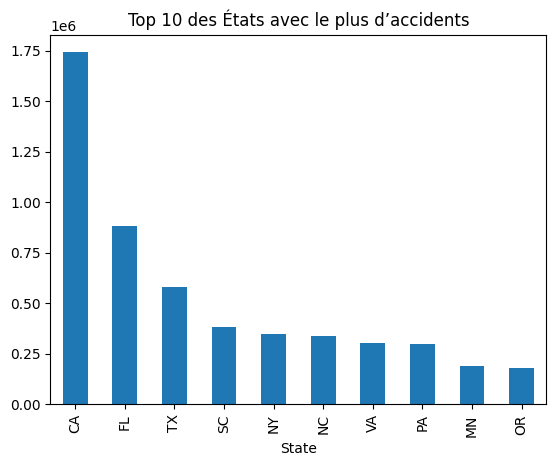

In [9]:
top_states = df['State'].value_counts().head(10)

top_states.plot(
    kind='bar',
    title='Top 10 des États avec le plus d’accidents'
)


In [10]:
                                 #Analyse par COMTÉ (County)

df['County'].value_counts().head(10)


County
Los Angeles       526851
Miami-Dade        251601
Orange            241275
Harris            181196
Dallas            157024
Mecklenburg       147265
Montgomery        136788
Wake              117890
San Bernardino    109631
Travis            107881
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 des villes avec le plus d’accidents'}, xlabel='City'>

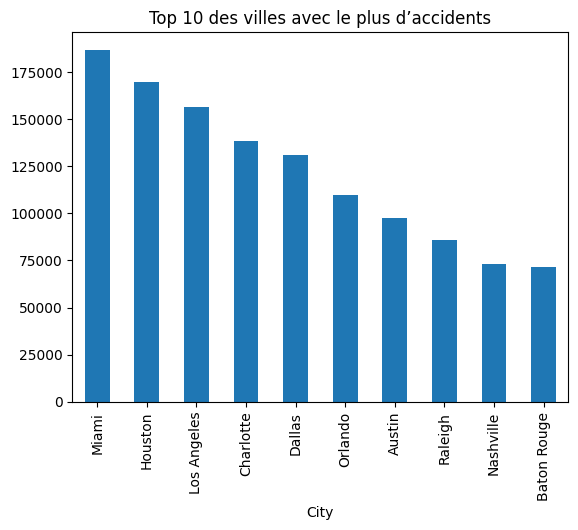

In [11]:
top_cities = df['City'].value_counts().head(10)

top_cities.plot(
    kind='bar',
    title='Top 10 des villes avec le plus d’accidents'
)


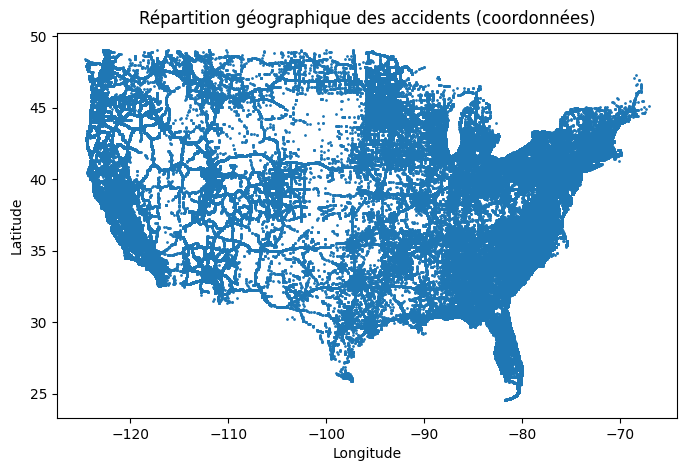

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['Start_Lng'], df['Start_Lat'], s=1)
plt.title('Répartition géographique des accidents (coordonnées)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


#  NETTOYAGE des colonnes géographiques

In [13]:
# Nettoyage : suppression de la colonne 'Country' inutile
df.drop(columns=['Country'], inplace=True)


In [14]:
df['State'].isna().sum()


np.int64(0)

In [15]:
df['City'] = df['City'].fillna('Unknown')


In [16]:
df['County'] = df['County'].fillna('Unknown')


In [ ]:
#creation de la variable Region à partir de l'état
state_to_region = {
    'CA':'West','AZ':'West','NV':'West','OR':'West','WA':'West',
    'TX':'South','FL':'South','GA':'South','NC':'South','SC':'South',
    'NY':'Northeast','MA':'Northeast','NJ':'Northeast','PA':'Northeast',
    'IL':'Midwest','OH':'Midwest','MI':'Midwest','WI':'Midwest'
}


In [ ]:
# Mapping des états aux régions
df['Region'] = df['State'].map(state_to_region)


La variable Region est dérivée de State afin de regrouper les États en grandes zones géographiques.

<Axes: title={'center': 'Répartition des accidents par région'}, ylabel='count'>

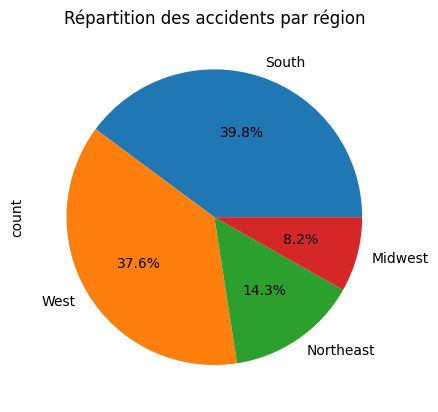

In [24]:
df['Region'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Répartition des accidents par région'
)


In [ ]:
# Création de la variable Zone_Type (Urban vs Rural)
df['Zone_Type'] = df['City'].apply(
    lambda x: 'Urban' if x != 'Unknown' else 'Rural'
)


In [23]:
df['Zone_Type'].value_counts(normalize=True) * 100


Zone_Type
Urban    99.996726
Rural     0.003274
Name: proportion, dtype: float64

In [ ]:
# Création de la colonne Accident_Count_By_State
accidents_by_state = df['State'].value_counts()

df['Accident_Count_By_State'] = df['State'].map(accidents_by_state)


In [ ]:
#creation de la colonne Accident_Density_Level
#Transformer un chiffre brut en niveau lisible métier
low = df['Accident_Count_By_State'].quantile(0.33)
high = df['Accident_Count_By_State'].quantile(0.66)

def density_level(x):
    if x <= low:
        return 'Low'
    elif x <= high:
        return 'Medium'
    else:
        return 'High'

df['Accident_Density_Level'] = df['Accident_Count_By_State'].apply(density_level)


In [ ]:
#Créer un indicateur de risque global par state
# etape 1 : calcul des indicateurs par state
state_metrics = df.groupby('State').agg(
    Total_Accidents=('ID', 'count'),
    Avg_Severity=('Severity', 'mean')
).reset_index()


In [ ]:
# etape 2 : definir les seuils
def risk_level(row):
    if row['Total_Accidents'] > high and row['Avg_Severity'] >= 3:
        return 'High Risk'
    elif row['Total_Accidents'] > low:
        return 'Medium Risk'
    else:
        return 'Low Risk'

state_metrics['State_Risk_Level'] = state_metrics.apply(risk_level, axis=1)


In [ ]:
# etape 3 : merge avec le df principal
df = df.merge(
    state_metrics[['State', 'State_Risk_Level']],
    on='State',
    how='left'
)


In [ ]:
# Création de la colonne Is_High_Accident_State qui contient des variables binaires
# Indicateur si l'état est dans le top 20% des états avec le plus d'accidents
threshold = df['Accident_Count_By_State'].quantile(0.80)

df['Is_High_Accident_State'] = df['Accident_Count_By_State'].apply(
    lambda x: 1 if x >= threshold else 0
)
